# Normalizing the heavy-pair EEC to LO gluon jets

Compare the same heavy-quark-pair numerator divided by either the pair-containing jet rate
or the LO gluon-jet rate in an infinitesimal $(p_T,y_J)$ bin. The main cases are pAu at
$\sqrt{s_{NN}}=200$ GeV, $y_J=2$, $p_T=5,7.5,10$ GeV. The previous LHC bin
($5020$ GeV, $y_J=3$, $p_T=25$ GeV, Pb) is a reference.
All cases use $m_Q=1.3$ GeV, $R_J=0.6$, and $c=0.75$.

Let $W_X(R)$ be the energy-weighted differential pair cross section, $D_X$ the pair-jet
cross section integrated over $R<R_J$, and $G_X$ the LO gluon-jet cross section.
Then
$$C_X^{\rm pair}(R)=\frac{W_X(R)}{D_X},\qquad
C_X^{g}(R)=\frac{W_X(R)}{G_X}=f_X C_X^{\rm pair}(R),\qquad f_X=\frac{D_X}{G_X},$$
$$R_{pA}^{g}(R)=\frac{f_A}{f_p}R_{pA}^{\rm pair}(R).$$
The multiplier is independent of $R$: the new normalization restores the nuclear modification
of the pair rate per gluon jet. It does not change the logarithmic angular slope of the ratio.
The individual $C_X^g$ start at $O(\alpha_s)$; their nuclear ratio does not require a choice of
the common coupling or the target-independent numerator prefactor. No extra $1/A$ is used.

**Adjoint dipole:** In the same large-$N_c$, factorized approximation as the pair numerator,
$S_{{\rm adj},X}(r)=S_{F,X}(r)^2$. With
$F_F(q)=\int d^2r\,e^{-iq\cdot r}S_F(r)/(2\pi)^2$,
$$F_{{\rm adj},X}(P)=\int d^2q\,F_{F,X}(q)F_{F,X}(P-q)\equiv O_X(P).$$
At nonzero $P$ the LO hybrid gluon-jet cross section is proportional to
$S_{\perp,X}x_pg_p(x_p,\mu^2)F_{{\rm adj},X}(P)$.
For both implemented dipoles $S_F^2$ is obtained by replacing the input $Q_s$ by
$\sqrt{2}Q_s$ in the **same** model. This is a color-representation change, separate from
the nuclear enhancement $Q_{s,A}^2=c A^{1/3}Q_{s,p}^2$.

For GBW, $O_X(P)=e^{-P^2/(2Q_{s,X}^2)}/(2\pi Q_{s,X}^2)$ cancels exactly.
For MV, evaluate the adjoint transform independently and check the convolution identity.
Using a fundamental dipole for the gluon denominator would be incorrect. Finite-$N_c$
Casimir scaling ($C_A/C_F=9/4$) is not mixed into the present large-$N_c$ numerator.

Reference for the hybrid gluon spectrum and $N_{\rm adj}=2N_F-N_F^2$:
[Lappi & Mäntysaari, arXiv:1309.6963, Eqs. (9)–(12)](https://arxiv.org/abs/1309.6963).
The numerical EEC results below are our calculation, not results from that reference.

In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
from IPython.display import display
from dataclasses import dataclass, replace, asdict
from functools import lru_cache
from pathlib import Path
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.fft import fht, fhtoffset
from scipy.integrate import quad, simpson
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
from scipy.special import j0, ndtri
from scipy.stats import qmc


@dataclass(frozen=True)
class Physics:
    sqrt_s: float = 200.0       # nucleon-nucleon CM energy [GeV]
    y_J: float = 2.0             # positive rapidity = proton-going direction
    p_T: float = 5.0            # infinitesimal jet bin [GeV]
    m_Q: float = 1.3             # charm mass [GeV], fixed phenomenological input
    R_J: float = 0.6
    A: float = 197.0             # Au
    c_nuclear: float = 0.75      # Eq. (43), vary over 0.5--1.0
    Qs0_sq: float = 1.0          # [GeV^2]
    x0: float = 3.04e-4
    lambda_s: float = 0.29
    Lambda_MV: float = 0.2       # [GeV]
    z_min: float = 0.0           # 0 reproduces the notes; same cut in both integrals

    def __post_init__(self):
        if not (self.sqrt_s > 0 and self.p_T > 0 and self.m_Q > 0):
            raise ValueError('sqrt_s, p_T and m_Q must be positive.')
        if not (0 < self.R_J <= 1 and 0 <= self.z_min < 0.5):
            raise ValueError('Use 0 < R_J <= 1 and 0 <= z_min < 0.5.')
        if min(self.A, self.c_nuclear, self.Qs0_sq, self.x0, self.Lambda_MV) <= 0:
            raise ValueError('Target and dipole parameters must be positive.')
        if not (0 < self.x_p < 1 and 0 < self.x_t < 1):
            raise ValueError('The selected kinematics give an unphysical momentum fraction.')

    @property
    def x_p(self):
        return self.p_T * np.exp(self.y_J) / self.sqrt_s

    @property
    def x_t(self):
        return self.p_T * np.exp(-self.y_J) / self.sqrt_s

    def Qs(self, target):
        if target not in ('p', 'A'):
            raise ValueError("target must be 'p' or 'A'")
        enhancement = 1.0 if target == 'p' else self.c_nuclear * self.A**(1/3)
        return np.sqrt(self.Qs0_sq * (self.x0/self.x_t)**self.lambda_s * enhancement)


@dataclass(frozen=True)
class Numerics:
    power: int = 18              # 2**power points in each independent Sobol scramble
    repeats: int = 8             # uncertainty from independent scrambles
    n_R: int = 48                # Gauss-Legendre nodes for the jet-rate denominator
    seed: int = 260922
    fft_n: int = 16384           # MV Hankel table

    def __post_init__(self):
        if self.power < 5 or self.repeats < 2 or self.n_R < 8 or self.fft_n < 1024:
            raise ValueError('Numerical settings are too small for this solver.')


PHYSICS = Physics()
NUMERICS = Numerics()
MODEL = 'MV'                    # 'GBW' or 'MV'
COMPARE_MODELS = True           # False runs only MODEL
RUN_PARAMETER_SCAN = True
RUN_CONVERGENCE = True
R_L = np.geomspace(0.008, PHYSICS.R_J, 65)
OUTPUT = Path('gluon_normalization_results')
OUTPUT.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 115, 'savefig.dpi': 180, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2,
})

CASES = {
    'RHIC_5': PHYSICS,
    'RHIC_7p5': replace(PHYSICS, p_T=7.5),
    'RHIC_10': replace(PHYSICS, p_T=10.),
    'LHC_25': replace(PHYSICS, sqrt_s=5020., p_T=25., y_J=3., A=208.),
}
R_L = np.unique(np.r_[np.geomspace(.008, PHYSICS.R_J, 65), .1, .3, .6])
RUN_CONVERGENCE = True

## Dipoles and the unchanged pair solver

The solver is included so this notebook can be run independently. Both dipole models use the same GBW estimate of the input saturation scale as before.

In [2]:
class GBWDipole:
    name = 'GBW'

    def __init__(self, Qs, Lambda=0.2, fft_n=16384):
        self.Qs = float(Qs)

    def S(self, r):
        r = np.asarray(r, dtype=float)
        return np.exp(-r*r*self.Qs**2/4)

    def F(self, q):
        q = np.asarray(q, dtype=float)
        return np.exp(-q*q/self.Qs**2)/(np.pi*self.Qs**2)

    def log_F(self, q):
        return -np.asarray(q)**2/self.Qs**2 - np.log(np.pi*self.Qs**2)

    @property
    def Q_operational(self):
        # Defined by S(2/Q_operational) = exp(-1).
        return self.Qs


class MVDipole:
    name = 'MV'

    def __init__(self, Qs, Lambda=0.2, fft_n=16384):
        self.Qs, self.Lambda = float(Qs), float(Lambda)
        Q = self.Qs
        r = np.geomspace(1e-9/Q, 1e3/Q, fft_n)
        dln = np.log(r[1]/r[0])
        bias = 0.5
        offset = fhtoffset(dln, mu=0, initial=0, bias=bias)
        q = np.exp(offset)/r[::-1]
        # Subtract a smooth Gaussian and transform it analytically. This reduces
        # cancellation/ringing without changing the coordinate-space MV model.
        a = Q**2/4 * np.log(np.e + Q/self.Lambda)
        residual = r*(self.S(r) - np.exp(-a*r*r))
        fq = (fht(residual, dln, mu=0, offset=offset, bias=bias)/(2*np.pi*q)
              + np.exp(-q*q/(4*a))/(4*np.pi*a))
        keep = (q >= 1e-3*Q) & (q <= 1e3*Q)
        self.q_grid, self.f_grid = q[keep], fq[keep]
        if np.any(~np.isfinite(self.f_grid)) or np.any(self.f_grid <= 0):
            raise ArithmeticError('MV transform lost positivity; refine the Hankel grid.')
        self.q_min, self.q_max = self.q_grid[[0, -1]]
        self._log_interp = PchipInterpolator(np.log(self.q_grid), np.log(self.f_grid))
        def moment(power):
            def integrand(t):
                if t == 0:
                    return 0.0
                return t**power*np.exp(-t*t/4*np.log(np.e+Q/(self.Lambda*t)))
            return quad(integrand, 0, 30, epsabs=1e-12, epsrel=2e-11)[0]
        self.F0 = moment(1)/(2*np.pi*Q**2)
        self.curvature = moment(3)/(8*np.pi*Q**4)
        self.tail_coefficient_ratio = self.f_grid[-1]*2*np.pi*self.q_max**4/Q**2

    def S(self, r):
        r = np.asarray(r, dtype=float)
        rr = np.maximum(r, np.finfo(float).tiny)
        logarithm = np.logaddexp(1.0, -np.log(rr)-np.log(self.Lambda))
        return np.exp(-r*r*self.Qs**2/4*logarithm)

    def F(self, q):
        q = np.abs(np.asarray(q, dtype=float))
        safe = np.clip(q, self.q_min, self.q_max)
        interpolated = np.exp(self._log_interp(np.log(safe)))
        # Taylor series only below 10^-3 Qs. At very high q use a continuous
        # q^-4 continuation; its coefficient and weight are explicitly checked.
        low = self.F0 - self.curvature*q*q
        high = self.f_grid[-1]*(self.q_max/np.maximum(q, self.q_min))**4
        return np.where(q < self.q_min, low,
                        np.where(q > self.q_max, high, interpolated))

    def log_F(self, q):
        return np.log(self.F(q))

    @property
    def Q_operational(self):
        return brentq(lambda Q: Q*Q-self.Qs**2*np.log(np.e+Q/(2*self.Lambda)),
                      self.Qs, 100*self.Qs)


# To add a model: implement S(r), F(q), log_F(q), Q_operational and Qs,
# then register its constructor here. Non-GBW models use generic importance sampling.
DIPOLE_MODELS = {'GBW': GBWDipole, 'MV': MVDipole}


@lru_cache(maxsize=64)
def make_dipole(model, Qs, Lambda=0.2, fft_n=16384):
    if model not in DIPOLE_MODELS:
        raise ValueError(f'Unknown dipole {model!r}; choose {list(DIPOLE_MODELS)}')
    return DIPOLE_MODELS[model](Qs, Lambda, fft_n)


def scale_table(cfg, numerics):
    rows = []
    for model in DIPOLE_MODELS:
        for target in ('p', 'A'):
            d = make_dipole(model, cfg.Qs(target), cfg.Lambda_MV, numerics.fft_n)
            rows.append(dict(model=model, target=target, x_p=cfg.x_p, x_t=cfg.x_t,
                             Qs_GeV=d.Qs, Q_operational_GeV=d.Q_operational,
                             R_Qs=4*d.Qs/cfg.p_T,
                             R_operational=4*d.Q_operational/cfg.p_T))
    return pd.DataFrame(rows)

In [3]:
def splitting_kernel(kx, ky, lx, ly, z, mass):
    Dk = kx*kx + ky*ky + mass*mass
    Dl = lx*lx + ly*ly + mass*mass
    return 0.5*(mass*mass*(1/Dk-1/Dl)**2
                + (z*z+(1-z)**2)*((kx/Dk-lx/Dl)**2+(ky/Dk-ly/Dl)**2))


def draw_phase_space(model, cfg, target, num, seed, extra_dimension=False,
                     proposal_scale=1.0):
    u = qmc.Sobol(d=6 if extra_dimension else 5, scramble=True,
                  seed=seed).random_base2(num.power)
    z = cfg.z_min+(1-2*cfg.z_min)*u[:, 0]
    phi = 2*np.pi*u[:, 1]
    Q, P = cfg.Qs(target), cfg.p_T
    dipole = make_dipole(model, Q, cfg.Lambda_MV, num.fft_n)
    if model == 'GBW':
        # Exactly sample F(q)F(q-P)/C(P). Never evaluate exp[-P^2/(2 Qs^2)].
        eps = np.finfo(float).eps
        qx = P/2 + Q/2*ndtri(np.clip(u[:, 2], eps, 1-eps))
        qy = Q/2*ndtri(np.clip(u[:, 3], eps, 1-eps))
        weights = np.ones(len(u))
        log_overlap = -P*P/(2*Q*Q)-np.log(2*np.pi*Q*Q)
        tail_fraction = 0.0
    else:
        # Two endpoint peaks plus a broad midpoint component cover the plane.
        # Each component is a normalized two-dimensional Student-t with nu=2.
        centers = np.array([0.0, P, P/2])
        probabilities = np.array([0.45, 0.45, 0.10])
        core = Q*np.sqrt(np.log(np.e+Q/cfg.Lambda_MV)/2)
        scales = proposal_scale*np.array([core, core, max(Q, P/4)])
        component = np.searchsorted(np.cumsum(probabilities), u[:, 2])
        radius = scales[component]*np.sqrt(2*u[:, 3]/(1-u[:, 3]))
        angle = 2*np.pi*u[:, 4]
        qx = centers[component]+radius*np.cos(angle)
        qy = radius*np.sin(angle)
        proposal = np.zeros(len(u))
        for prob, center, scale in zip(probabilities, centers, scales):
            t2 = ((qx-center)**2+qy*qy)/(2*scale*scale)
            proposal += prob/(2*np.pi*scale*scale)*(1+t2)**-2
        q1, q2 = np.hypot(qx, qy), np.hypot(qx-P, qy)
        log_weights = dipole.log_F(q1)+dipole.log_F(q2)-np.log(proposal)
        shift = np.max(log_weights)
        weights = np.exp(log_weights-shift)
        log_overlap = shift+np.log(weights.mean())
        weights /= weights.mean()   # this normalization cancels in every EEC ratio
        outside = ((q1 > dipole.q_max) | (q2 > dipole.q_max)
                   if hasattr(dipole, 'q_max') else np.zeros(len(u), dtype=bool))
        tail_fraction = weights[outside].sum()/weights.sum()
    return dict(z=z, b=z*(1-z), cos_phi=np.cos(phi), sin_phi=np.sin(phi),
                qx=qx, qy=qy, weights=weights,
                ess_fraction=weights.sum()**2/(len(weights)*np.dot(weights, weights)),
                tail_fraction=tail_fraction, log_overlap=log_overlap,
                radial_u=u[:, -1] if extra_dimension else None)


def angular_integrands(radii, sample, cfg, constant_kernel=False):
    z, b, weight = sample['z'], sample['b'], sample['weights']
    unweighted, weighted = [], []
    for R in np.asarray(radii):
        if constant_kernel:
            K = np.ones_like(z)
        else:
            k = b*cfg.p_T*R
            kx, ky = k*sample['cos_phi'], k*sample['sin_phi']
            lx, ly = kx+z*cfg.p_T-sample['qx'], ky-sample['qy']
            K = splitting_kernel(kx, ky, lx, ly, z, cfg.m_Q)
        base = weight*b*b*K
        unweighted.append(R*np.mean(base))
        weighted.append(R*np.mean(b*base))
    # Common angular and z-interval factors cancel in the normalized observable.
    return np.array(unweighted), np.array(weighted)


def solve_target(model, cfg, num, R, target, proposal_scale=1.0,
                 constant_kernel=False):
    R = np.asarray(R, dtype=float)
    if R.ndim != 1 or np.any(R < 0) or np.any(~np.isfinite(R)):
        raise ValueError('R must be a finite one-dimensional nonnegative array.')
    nodes, gauss_weights = leggauss(num.n_R)
    Rq, wq = (nodes+1)*cfg.R_J/2, gauss_weights*cfg.R_J/2
    all_R = np.r_[R, Rq]
    curves, denominators, mean_weights, ess, tails, overlaps = [], [], [], [], [], []
    probability_curves, conditional_weights = [], []
    for rep in range(num.repeats):
        sample = draw_phase_space(model, cfg, target, num, num.seed+rep,
                                  proposal_scale=proposal_scale)
        U, W = angular_integrands(all_R, sample, cfg, constant_kernel)
        denominator = np.dot(wq, U[len(R):])
        if not np.isfinite(denominator) or denominator <= 0:
            raise ArithmeticError('The pair-jet normalization must be finite and positive.')
        curve = W[:len(R)]/denominator
        curve[R > cfg.R_J] = 0.0
        probability = U[:len(R)]/denominator
        probability[R > cfg.R_J] = 0.0
        mean_b = np.divide(W[:len(R)], U[:len(R)], out=np.full(len(R), np.nan),
                           where=U[:len(R)] > 0)
        probability_curves.append(probability)
        conditional_weights.append(mean_b)
        curves.append(curve)
        denominators.append(denominator)
        mean_weights.append(np.dot(wq, W[len(R):])/denominator)
        ess.append(sample['ess_fraction'])
        tails.append(sample['tail_fraction'])
        overlaps.append(sample['log_overlap'])
    curves = np.array(curves)
    return dict(R=R, samples=curves, C=curves.mean(0),
                probability_samples=np.array(probability_curves),
                conditional_weight_samples=np.array(conditional_weights),
                probability=np.mean(probability_curves, axis=0),
                conditional_weight=np.mean(conditional_weights, axis=0),
                C_error=curves.std(0, ddof=1)/np.sqrt(num.repeats),
                denominator=np.array(denominators), mean_weight=np.array(mean_weights),
                ess_fraction=np.array(ess), tail_fraction=np.array(tails),
                log_overlap=np.array(overlaps))


def solve_pair(model, cfg, num, R, proposal_scale=1.0):
    start = time.perf_counter()
    proton = solve_target(model, cfg, num, R, 'p', proposal_scale)
    nucleus = solve_target(model, cfg, num, R, 'A', proposal_scale)
    # Common random numbers correlate pp/pA estimates; form ratios scramble by scramble.
    ratios = np.divide(nucleus['samples'], proton['samples'],
                       out=np.full_like(nucleus['samples'], np.nan),
                       where=proton['samples'] > 0)
    ratio = np.divide(nucleus['C'], proton['C'], out=np.full_like(proton['C'], np.nan),
                      where=proton['C'] > 0)
    return dict(model=model, physics=cfg, numerics=num, R=np.asarray(R),
                p=proton, A=nucleus, ratio=ratio,
                ratio_error=ratios.std(0, ddof=1)/np.sqrt(num.repeats),
                ratio_samples=ratios, seconds=time.perf_counter()-start)

In [4]:
def direct_hankel(dipole, q):
    Q = dipole.Qs
    value, error = quad(lambda t: t*j0(q*t/Q)*float(dipole.S(t/Q)),
                        0, 30, epsabs=1e-12, epsrel=1e-9, limit=1000)
    return value/(2*np.pi*Q*Q)


def dipole_checks(cfg, num):
    rows = []
    for model in ('GBW', 'MV'):
        for target in ('p', 'A'):
            dipole = make_dipole(model, cfg.Qs(target), cfg.Lambda_MV, num.fft_n)
            # Only use direct quadrature where the reference is above cancellation noise.
            probes = ([0, dipole.Qs, 2*dipole.Qs, 3*dipole.Qs] if model == 'GBW'
                      else [0, dipole.Qs, 5*dipole.Qs, cfg.p_T/2, cfg.p_T])
            errs = [abs(float(dipole.F(q))/direct_hankel(dipole, q)-1) for q in probes]
            if model == 'MV':
                qq = np.geomspace(dipole.q_min, dipole.q_max, 16001)
                norm = simpson(2*np.pi*qq*qq*dipole.F(qq), x=np.log(qq))
                norm += np.pi*dipole.F0*dipole.q_min**2
                norm -= np.pi/2*dipole.curvature*dipole.q_min**4
                norm += np.pi*dipole.f_grid[-1]*dipole.q_max**2
                tail = dipole.tail_coefficient_ratio
                assert abs(norm-1) < 2e-4, f'MV transform normalization: {norm}'
                assert abs(tail-1) < .02, f'MV large-q coefficient: {tail}'
            else:
                norm, tail = 1.0, np.nan
            assert max(errs) < 2e-5, f'{model} Hankel check failed: {max(errs)}'
            rows.append(dict(model=model, target=target, hankel_max_relative_error=max(errs),
                             integral_d2q_F=norm, tail_over_Qs2_over_2pi=tail))
    return pd.DataFrame(rows)


def algebra_checks(cfg, num):
    rng = np.random.default_rng(81)
    kx, ky, lx, ly = rng.normal(size=(4, 1000))
    z = rng.uniform(size=1000)
    assert np.all(splitting_kernel(kx, ky, lx, ly, z, cfg.m_Q) >= 0)
    assert np.all(splitting_kernel(kx, ky, kx, ky, z, cfg.m_Q) == 0)
    cheap = replace(num, power=12, repeats=2, n_R=16)
    radii = np.linspace(.01, cfg.R_J, 11)
    toy_cfg = replace(cfg, z_min=0)
    toy = solve_target('GBW', toy_cfg, cheap, radii, 'p', constant_kernel=True)
    expected = 3*radii/(7*cfg.R_J**2)
    toy_error = np.max(np.abs(toy['C']/expected-1))
    assert toy_error < 3e-5
    assert abs(toy['mean_weight'].mean()-3/14) < 3e-6
    unity = {}
    for model in ('GBW', 'MV'):
        result = solve_pair(model, replace(cfg, A=1, c_nuclear=1), cheap, radii)
        unity[model] = np.max(np.abs(result['ratio']-1))
        assert unity[model] < 1e-13
    return dict(kernel_positive=True, kernel_zero_at_k_equals_l=True,
                constant_kernel_relative_error=float(toy_error),
                A1_identity_error=unity)


def disk_check(model, cfg, num, target):
    # Independent 6D quadrature: sample k uniformly in its allowed disk,
    # k = b P R_J sqrt(u). This bypasses the angular delta and Gauss-R integration.
    den, avg, bad_mass, endpoints, tail_kernel = [], [], [], [], []
    for rep in range(num.repeats):
        s = draw_phase_space(model, cfg, target, num, num.seed+10000+rep,
                             extra_dimension=True)
        z, b = s['z'], s['b']
        radius = cfg.R_J*np.sqrt(s['radial_u'])
        k = b*cfg.p_T*radius
        kx, ky = k*s['cos_phi'], k*s['sin_phi']
        K = splitting_kernel(kx, ky, kx+z*cfg.p_T-s['qx'], ky-s['qy'], z, cfg.m_Q)
        w = s['weights']*b*b*K
        den.append(cfg.R_J**2/2*w.mean())
        avg.append(np.sum(w*b)/np.sum(w))
        mass_ratio = (cfg.m_Q**2+k*k)/(b*cfg.p_T**2)
        bad_mass.append(w[mass_ratio > .25].sum()/w.sum())
        endpoints.append(w[(z < .1) | (z > .9)].sum()/w.sum())
        d = make_dipole(model, cfg.Qs(target), cfg.Lambda_MV, num.fft_n)
        far = ((np.hypot(s['qx'], s['qy']) > d.q_max)
               | (np.hypot(s['qx']-cfg.p_T, s['qy']) > d.q_max)
               if hasattr(d, 'q_max') else np.zeros(len(z), dtype=bool))
        tail_kernel.append(w[far].sum()/w.sum())
    return dict(denominator=np.array(den), mean_weight=np.array(avg),
                fraction_MJ2_over_PT2_gt_025=np.mean(bad_mass),
                fraction_endpoint_z01=np.mean(endpoints),
                kernel_weight_in_asymptotic_tail=np.mean(tail_kernel))


def result_frame(result):
    return pd.DataFrame(dict(R_L=result['R'], EEC_pp=result['p']['C'],
                             EEC_pp_error=result['p']['C_error'],
                             EEC_pA=result['A']['C'], EEC_pA_error=result['A']['C_error'],
                             R_pA=result['ratio'], R_pA_error=result['ratio_error']))

## Apply the gluon denominator

The pair solver samples the normalized product $F_F(q)F_F(P-q)/O(P)$.
Its stored `denominator` is therefore the pair-rate integral **after removing** $O(P)$ and
common factors. Multiplying its EEC by that denominator recovers the similarly stripped
weighted numerator. We then multiply by $O(P)/F_{\rm adj}(P)$, which is exactly one in
this model. For MV, calculating this factor explicitly includes the integration error
on the overlap instead of cancelling it against itself numerically.

The tables report $f_A/f_p$ and the two nuclear ratios. `reduced_W_*` and `reduced_D_*`
omit the common target-independent cross-section prefactor (including $\alpha_s$ and
angular/Jacobian factors); they are not absolute EECs or absolute probabilities.

In [5]:
def gluon_normalize(result):
    cfg, num, model = result['physics'], result['numerics'], result['model']
    reduced, rates, adjoint, overlap_checks = {}, {}, {}, []
    for target in ('p','A'):
        d = result[target]
        adj = make_dipole(model, np.sqrt(2)*cfg.Qs(target), cfg.Lambda_MV, num.fft_n)
        log_g = float(adj.log_F(cfg.p_T))
        # Logs retain the exact Gaussian cancellation even for tiny hard yields.
        correction = np.exp(d['log_overlap']-log_g)
        rates[target] = d['denominator']*correction
        reduced[target] = d['samples']*rates[target][:,None]
        adjoint[target] = log_g
        overlap_checks.append(dict(model=model, target=target,
            convolution_over_adjoint=correction.mean(),
            numerical_error=correction.std(ddof=1)/np.sqrt(len(correction)),
            direct_hankel_relative_error=(abs(float(adj.F(cfg.p_T))/direct_hankel(adj,cfg.p_T)-1)
                                         if model=='MV' else 0.)))
    new_samples = reduced['A']/reduced['p']
    factor_samples = rates['A']/rates['p']
    new_ratio = reduced['A'].mean(0)/reduced['p'].mean(0)
    factor = rates['A'].mean()/rates['p'].mean()
    pair_ratio = ((reduced['A'].mean(0)/rates['A'].mean()) /
                  (reduced['p'].mean(0)/rates['p'].mean()))
    assert np.max(abs(new_ratio/pair_ratio-factor)) < 2e-13
    assert np.max(abs(new_samples/result['ratio_samples']-factor_samples[:,None])) < 2e-13
    return dict(R=result['R'], pair_ratio=pair_ratio, gluon_ratio=new_ratio,
        pair_error=result['ratio_error'], gluon_samples=new_samples,
        gluon_error=new_samples.std(0,ddof=1)/np.sqrt(num.repeats),
        rate_factor=factor, rate_factor_samples=factor_samples,
        rate_factor_error=factor_samples.std(ddof=1)/np.sqrt(num.repeats),
        reduced_W=reduced, reduced_D=rates, log_adjoint=adjoint,
        overlap_checks=overlap_checks)

results, summary_rows, checks = {}, [], []
for name, cfg in CASES.items():
    for model in ('GBW','MV'):
        base=solve_pair(model,cfg,NUMERICS,R_L)
        r=gluon_normalize(base)
        results[name,model]=r
        frame=pd.DataFrame(dict(R_L=R_L,
            R_pair=r['pair_ratio'], R_pair_error=r['pair_error'],
            R_gluon=r['gluon_ratio'], R_gluon_error=r['gluon_error'],
            reduced_W_pp=r['reduced_W']['p'].mean(0),
            reduced_W_pA=r['reduced_W']['A'].mean(0)))
        frame.to_csv(OUTPUT/f'{name}_{model}.csv',index=False)
        np.savez_compressed(OUTPUT/f'{name}_{model}_replicates.npz',R_L=R_L,
            ratio_gluon=r['gluon_samples'],ratio_pair=base['ratio_samples'],
            rate_factor=r['rate_factor_samples'],
            reduced_W_pp=r['reduced_W']['p'],reduced_W_pA=r['reduced_W']['A'],
            reduced_D_pp=r['reduced_D']['p'],reduced_D_pA=r['reduced_D']['A'])
        row=dict(case=name,model=model,p_T=cfg.p_T,y_J=cfg.y_J,
            sqrt_s=cfg.sqrt_s,rate_factor=r['rate_factor'],rate_factor_error=r['rate_factor_error'],
            max_ratio_error=r['gluon_error'].max(),
            max_difference_from_previous_pair_estimator=np.max(abs(r['pair_ratio']-base['ratio'])))
        for R in (.1,.3,.6):
            tag=str(R).replace('.','p')
            row['pair_R'+tag]=float(np.interp(R,R_L,r['pair_ratio']))
            row['gluon_R'+tag]=float(np.interp(R,R_L,r['gluon_ratio']))
        summary_rows.append(row)
        for c in r['overlap_checks']: checks.append(dict(case=name,**c))
        print(f"{name}, {model}: fA/fp={r['rate_factor']:.6f}; "
              f"gluon ratio={r['gluon_ratio'].min():.6f}--{r['gluon_ratio'].max():.6f}",flush=True)
summary=pd.DataFrame(summary_rows)
checks=pd.DataFrame(checks)
assert np.max(abs(checks.convolution_over_adjoint-1)) < .001
assert checks.direct_hankel_relative_error.max() < 2e-5
summary.to_csv(OUTPUT/'summary.csv',index=False)
checks.to_csv(OUTPUT/'adjoint_checks.csv',index=False)
display(summary)
display(checks)

RHIC_5, GBW: fA/fp=1.375599; gluon ratio=1.448090--1.515867


RHIC_5, MV: fA/fp=0.871912; gluon ratio=0.845480--0.854967


RHIC_7p5, GBW: fA/fp=1.160522; gluon ratio=1.193140--1.246601


RHIC_7p5, MV: fA/fp=0.907024; gluon ratio=0.887138--0.897359


RHIC_10, GBW: fA/fp=1.085754; gluon ratio=1.103792--1.141108


RHIC_10, MV: fA/fp=0.952995; gluon ratio=0.942434--0.950602


LHC_25, GBW: fA/fp=1.035975; gluon ratio=1.042941--1.062621


LHC_25, MV: fA/fp=0.993373; gluon ratio=0.986592--1.006687


,case,model,p_T,y_J,sqrt_s,rate_factor,rate_factor_error,max_ratio_error,max_difference_from_previous_pair_estimator,pair_R0p1,gluon_R0p1,pair_R0p3,gluon_R0p3,pair_R0p6,gluon_R0p6
0,RHIC_5,GBW,5.0,2.0,200.0,1.375599,0.000003,0.000005,4.361844e-12,1.100010,1.513172,1.085584,1.493328,1.052698,1.448090
1,RHIC_5,MV,5.0,2.0,200.0,0.871912,0.000045,0.000062,6.068547e-09,0.969958,0.845718,0.972263,0.847727,0.980566,0.854967
2,RHIC_7p5,GBW,7.5,2.0,200.0,1.160522,0.000002,0.000011,1.095954e-10,1.071503,1.243502,1.053868,1.223037,1.028106,1.193140
3,RHIC_7p5,MV,7.5,2.0,200.0,0.907024,0.000022,0.000041,1.823554e-09,0.978154,0.887208,0.979610,0.888530,0.989344,0.897359
4,RHIC_10,GBW,10.0,2.0,200.0,1.085754,0.000006,0.000019,2.956222e-10,1.048082,1.137959,1.031611,1.120076,1.016613,1.103792
5,RHIC_10,MV,10.0,2.0,200.0,0.952995,0.000018,0.000033,7.329714e-10,0.989081,0.942589,0.989336,0.942832,0.997489,0.950602
6,LHC_25,GBW,25.0,3.0,5020.0,1.035975,0.000017,0.000082,3.768005e-09,1.020104,1.056801,1.010366,1.046713,1.006725,1.042941
7,LHC_25,MV,25.0,3.0,5020.0,0.993373,0.000043,0.000183,3.503430e-08,0.993298,0.986715,0.996001,0.989400,1.013403,1.006687


,case,model,target,convolution_over_adjoint,numerical_error,direct_hankel_relative_error
0,RHIC_5,GBW,p,1.000000,0.000000,0.000000e+00
1,RHIC_5,GBW,A,1.000000,0.000000,0.000000e+00
2,RHIC_5,MV,p,1.000002,0.000005,4.766987e-11
3,RHIC_5,MV,A,0.999998,0.000009,9.563252e-10
4,RHIC_7p5,GBW,p,1.000000,0.000000,0.000000e+00
5,RHIC_7p5,GBW,A,1.000000,0.000000,0.000000e+00
6,RHIC_7p5,MV,p,0.999985,0.000006,4.272571e-11
7,RHIC_7p5,MV,A,0.999994,0.000007,9.394152e-12
8,RHIC_10,GBW,p,1.000000,0.000000,0.000000e+00
9,RHIC_10,GBW,A,1.000000,0.000000,0.000000e+00


## Normalization comparison

Solid curves use the LO gluon denominator; dashed curves retain the pair-jet denominator. Each solid/dashed pair differs by a constant multiplicative factor, not by an additive shift.

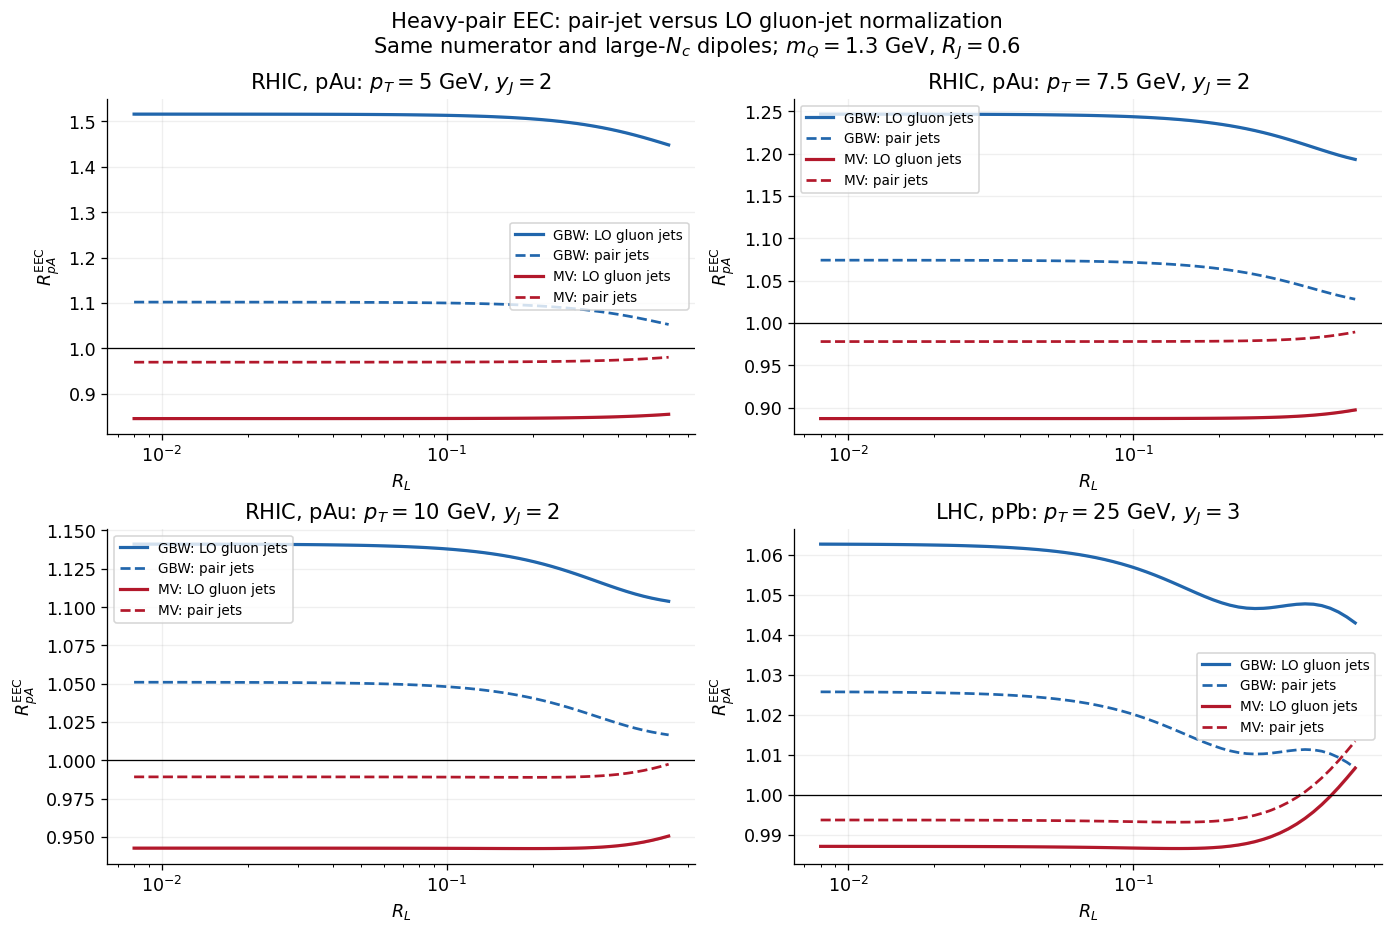

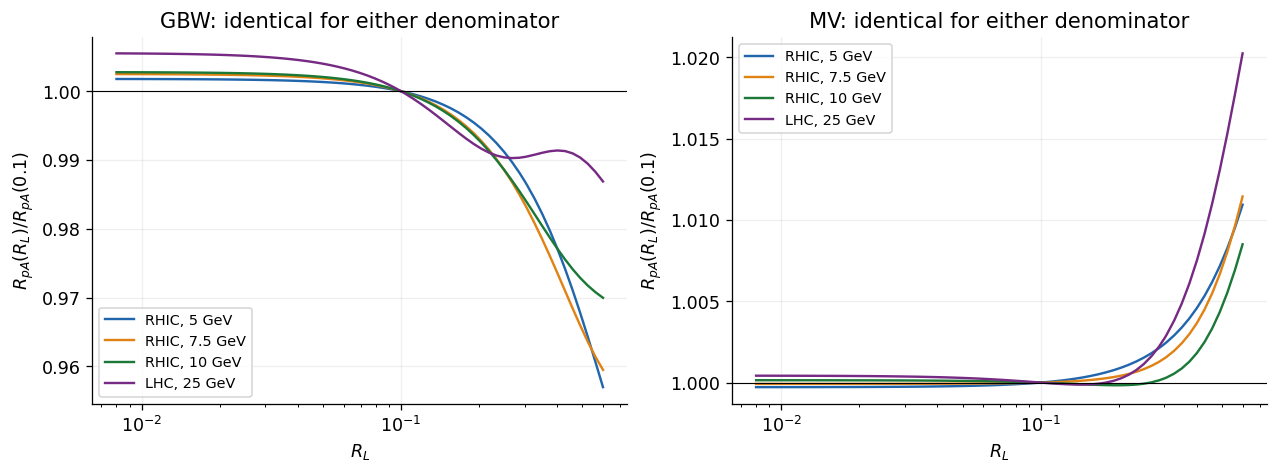

In [6]:
fig, axes=plt.subplots(2,2,figsize=(12,8),constrained_layout=True)
colors={'RHIC_5':'#2166ac','RHIC_7p5':'#e08214','RHIC_10':'#1b7837','LHC_25':'#762a83'}
for ax,(name,cfg) in zip(axes.flat,CASES.items()):
    for model,color in [('GBW','#2166ac'),('MV','#b2182b')]:
        r=results[name,model]
        ax.plot(R_L,r['gluon_ratio'],color=color,lw=2,label=f'{model}: LO gluon jets')
        ax.fill_between(R_L,r['gluon_ratio']-r['gluon_error'],r['gluon_ratio']+r['gluon_error'],color=color,alpha=.2)
        ax.plot(R_L,r['pair_ratio'],color=color,lw=1.7,ls='--',label=f'{model}: pair jets')
    ax.axhline(1,color='k',lw=.8)
    ax.set_xscale('log')
    collider='RHIC, pAu' if name.startswith('RHIC') else 'LHC, pPb'
    ax.set_title(rf'{collider}: $p_T={cfg.p_T:g}$ GeV, $y_J={cfg.y_J:g}$')
    ax.set_xlabel(r'$R_L$')
    ax.set_ylabel(r'$R_{pA}^{\mathrm{EEC}}$')
    ax.legend(fontsize=8.5)
fig.suptitle(r'Heavy-pair EEC: pair-jet versus LO gluon-jet normalization'+'\n'+
             r'Same numerator and large-$N_c$ dipoles; $m_Q=1.3$ GeV, $R_J=0.6$')
fig.savefig(OUTPUT/'normalization_comparison.png')
plt.show()

fig,axes=plt.subplots(1,2,figsize=(11,4),constrained_layout=True)
for ax,model in zip(axes,['GBW','MV']):
    for name,cfg in CASES.items():
        r=results[name,model]
        pair=r['pair_ratio']/np.interp(.1,R_L,r['pair_ratio'])
        gluon=r['gluon_ratio']/np.interp(.1,R_L,r['gluon_ratio'])
        assert np.max(abs(pair-gluon)) < 2e-13
        ax.plot(R_L,gluon,color=colors[name],label=f"{'RHIC' if name.startswith('RHIC') else 'LHC'}, {cfg.p_T:g} GeV")
    ax.axhline(1,color='k',lw=.7)
    ax.set_xscale('log')
    ax.set_xlabel(r'$R_L$')
    ax.set_ylabel(r'$R_{pA}(R_L)/R_{pA}(0.1)$')
    ax.set_title(model+': identical for either denominator')
    ax.legend(fontsize=9)
fig.savefig(OUTPUT/'unchanged_angular_shape.png')
plt.show()

## Numerical verification

Check the adjoint convolution with an independently transformed $S_F^2$ and direct radial
quadrature for MV. Double Sobol statistics for the most modified RHIC bin, and check the
unity limit when the two targets coincide. The prior RHIC notebook checks radial quadrature,
an independent disk integral, and the original Fourier transform.

In [7]:
convergence=[]
if RUN_CONVERGENCE:
    test_R=np.array([.1,.3,.6])
    for model in ('GBW','MV'):
        cfg=CASES['RHIC_5']
        fine=gluon_normalize(solve_pair(model,cfg,replace(NUMERICS,power=NUMERICS.power+1),test_R))
        base=results['RHIC_5',model]
        delta=np.max(abs(fine['gluon_ratio']-np.interp(test_R,R_L,base['gluon_ratio'])))
        assert delta<.001
        convergence.append(dict(case='RHIC_5',model=model,check='double samples',max_abs_change=delta))
        equal=replace(cfg,A=1.,c_nuclear=1.)
        cheap=replace(NUMERICS,power=12,repeats=2,n_R=16)
        unit=gluon_normalize(solve_pair(model,equal,cheap,test_R))
        delta=np.max(abs(unit['gluon_ratio']-1))
        assert delta<1e-13
        convergence.append(dict(case='identical targets',model=model,check='unity',max_abs_change=delta))
convergence=pd.DataFrame(convergence)
convergence.to_csv(OUTPUT/'convergence.csv',index=False)
display(convergence)
metadata=dict(cases={k:asdict(v) for k,v in CASES.items()},numerics=asdict(NUMERICS),
    adjoint_prescription='S_adj = S_F**2, consistent large-Nc mean-field approximation',
    observable='(weighted pair cross section / LO gluon cross section)_pA / same_pp',
    absolute_gluon_normalized_EEC_calculated=False,
    limitations=['Same massless-jet kinematics as previous notebooks; mass retained in splitting kernel',
        'Gluon projectile channel only; not the full inclusive-jet observable',
        'No BK evolution, NLO correction, fragmentation, detector effects, or finite-Nc numerator',
        'Numerical errors are not theory uncertainties'])
(OUTPUT/'run_metadata.json').write_text(json.dumps(metadata,indent=2))
print('All normalization and convergence checks passed.')

,case,model,check,max_abs_change
0,RHIC_5,GBW,double samples,0.000004
1,identical targets,GBW,unity,0.000000
2,RHIC_5,MV,double samples,0.000041
3,identical targets,MV,unity,0.000000


All normalization and convergence checks passed.


## Interpretation

The LO gluon denominator retains the target dependence of heavy-pair production per gluon jet.
It is therefore a useful complementary observable to the conditional pair-jet EEC. A larger
departure from unity can be a rate effect, even when the angular shape is unchanged.
The identity relating the two ratios is general for fixed bins and identical numerator cuts;
the numerical rate factors here depend on our dipole and kinematic approximations.

This is an $O(\alpha_s)$ numerator over an $O(1)$ eikonal denominator, which is the leading
nonzero contribution to this heavy-pair correlator per gluon jet. It does not yet describe
normalization to all experimental jets: quark and antiquark initiated jets must enter that
denominator, and relevant additional numerator channels must be included at the chosen accuracy.

The 5 GeV bin remains exploratory: $M_J^2/p_T^2\ge 4m_Q^2/p_T^2=0.2704$.
Exact massive kinematics would change the target and projectile momentum fractions within
the pair integrals, so the same fixed PDF and overlap cancellation would not persist in that form.
Opposite GBW and MV trends are a model dependence, not a robust identification of saturation.
No event yield, experimental significance, or absolute pair probability is inferred here.